In [1]:
import pandas as pd

data = pd.read_csv("F:/project/college project/code/data/procesed data/featured_stock_data.csv")

print(data.head())

        Open       High        Low      Close     Volume     Target  \
0  43.860911  43.908615  43.541316  43.820366   94318000  44.390385   
1  44.087487  44.678976  43.822747  44.390385  156171600  44.843540   
2  44.314061  44.931786  44.311673  44.843540  104879200  44.488182   
3  44.922261  45.074904  44.342694  44.488182  126585600  44.876945   
4  44.416631  45.194156  44.058874  44.876945  124140800  46.529770   

       MA_10      MA_50    Return  Volatility  
0  42.251723  39.373998  0.011117    0.012557  
1  42.517656  39.511731  0.013008    0.012680  
2  42.807914  39.733241  0.010208    0.012730  
3  43.070270  39.918812 -0.007924    0.013321  
4  43.395590  40.113726  0.008739    0.012650  


In [4]:
X = data[['Open', 'High', 'Low','Close','Volume', 'MA_10', 'MA_50', 'Return', 'Volatility']]
y = data['Target']
print(X.shape)
print(y.shape)


(1793, 9)
(1793,)


In [5]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [6]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

# Print Results
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 17.56396072897738
Mean Squared Error (MSE): 533.6751440876955
Root Mean Squared Error (RMSE): 23.101410002155614
R2 Score: 0.20341902105343246


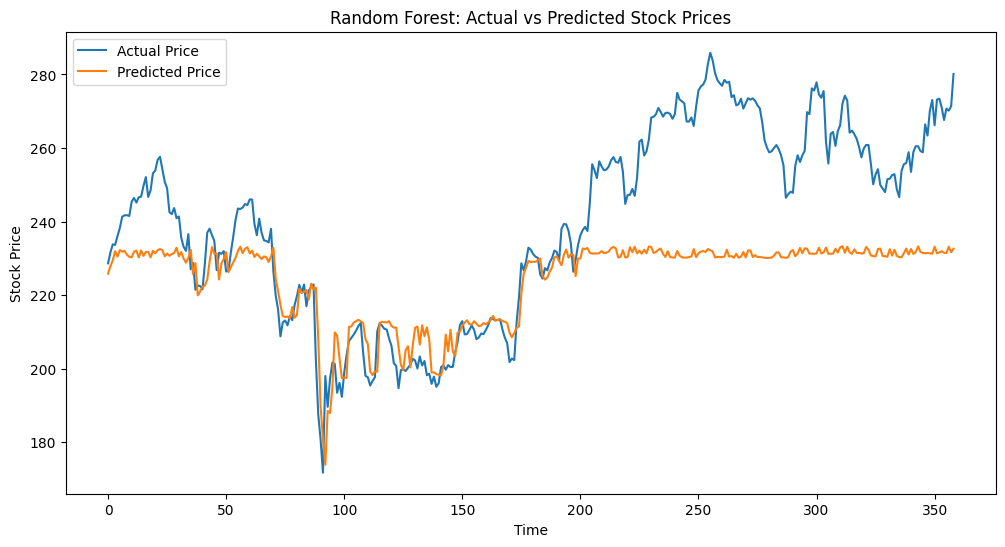

In [8]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred_rf, label="Predicted Price")

plt.title("Random Forest: Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()

plt.show()